# LADA - Monte Carlo Cross-Validation con Estrategia Global

## Objetivo
Validar la estabilidad del sistema de clustering multinivel mediante **Monte Carlo Cross-Validation** (repeated random subsampling).

## Metodologia
- Se buscan los mejores hiperparametros **globales** una sola vez (no por Level 1)
- En cada iteracion se selecciona **70% del TRAIN** sin reemplazo
- Se re-ejecuta el pipeline completo: clustering en 3 niveles + progressive fallback
- Se evalua siempre en el **mismo TEST fijo** (preserva validacion temporal)
- Se repite **N=30 veces** para generar distribuciones empiricas de metricas

### Por que no bootstrap clasico?
El remuestreo con reemplazo genera observaciones duplicadas que sesgan la formacion de clusters
al sobre-ponderar ciertas regiones del espacio de features, desplazando artificialmente los centroides.
Monte Carlo CV selecciona subconjuntos sin reemplazo, garantizando que cada observacion aparezca
como maximo una vez en cada submuestra.

### Justificacion
El notebook `LADA_validacion_estrategia_algoritmos.ipynb` demostro que usar un solo algoritmo global
(GMM) es estadisticamente mejor que propagar desde Level 1 (Wilcoxon p < 0.001). Este notebook
valida que los resultados son estables y no dependen de una configuracion favorable de los clusters.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, mean_squared_error, mean_squared_error, mean_squared_error, mean_squared_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
from scipy import stats
import skfuzzy as fuzz
import time
import random
import warnings
warnings.filterwarnings('ignore')

print('Imports completados')

Imports completados


## 1. Carga de Datos

In [22]:
# Cargar los 6 datasets
DATA_PATH = '../data/'

df_materias = pd.read_parquet(f'{DATA_PATH}historial_materias_estudiante_anonymized.parquet')
print(f' Historial de materias: {df_materias.shape[0]:,} registros, {df_materias.shape[1]} columnas')

df_rendimiento = pd.read_parquet(f'{DATA_PATH}historial_rendimiento_academico_estudiante_anonymized.parquet')
print(f' Rendimiento academico: {df_rendimiento.shape[0]:,} registros, {df_rendimiento.shape[1]} columnas')

df_percentiles = pd.read_parquet(f'{DATA_PATH}percentiles_academicos_estudiante_anonymized.parquet')
print(f' Percentiles academicos: {df_percentiles.shape[0]:,} registros, {df_percentiles.shape[1]} columnas')

df_info_actual = pd.read_parquet(f'{DATA_PATH}informacion_actual_estudiante_anonymized.parquet')
print(f' Informacion actual: {df_info_actual.shape[0]:,} registros, {df_info_actual.shape[1]} columnas')

df_riesgos = pd.read_parquet(f'{DATA_PATH}riesgos_historicos_estudiante_pregrado_anonymized.parquet')
print(f' Riesgos historicos: {df_riesgos.shape[0]:,} registros, {df_riesgos.shape[1]} columnas')

df_facultades_departamentos = pd.read_parquet(f'{DATA_PATH}oferta_academica_anonymized.parquet')
print(f' Oferta Academica: {df_facultades_departamentos.shape[0]:,} registros, {df_facultades_departamentos.shape[1]} columnas')

 Historial de materias: 4,931,740 registros, 15 columnas
 Rendimiento academico: 611,654 registros, 22 columnas
 Percentiles academicos: 158,429 registros, 11 columnas
 Informacion actual: 222,407 registros, 30 columnas
 Riesgos historicos: 369,370 registros, 12 columnas
 Oferta Academica: 334,547 registros, 5 columnas


## 2. Preprocesamiento (identico a v4)

In [23]:
# ============================================================================
# PREPROCESAMIENTO DE MATERIAS
# ============================================================================
print('1. Procesando historial de materias...')

df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].assign(
    EXITO=lambda x: (x['RESULTADO'] == 'APROBADO').astype('int8'),
    CODIGO_CURSO=lambda x: x['CODIGO_CURSO'].astype(str),
    PERIODO=lambda x: x['PERIODO'].astype(str)
)

# Deduplicar facultades por (CODIGO_CURSO, PERIODO)
df_facultades_clean = df_facultades_departamentos[
    ['CODIGO_CURSO', 'PERIODO', 'CODIGO_DEPARTAMENTO', 'CODIGO_FACULTAD']
].drop_duplicates(subset=['CODIGO_CURSO', 'PERIODO'], keep='first').astype({
    'CODIGO_CURSO': str,
    'PERIODO': str
})

# Merge por curso y periodo
df_materias_clean = df_materias_clean.merge(
    df_facultades_clean,
    on=['CODIGO_CURSO', 'PERIODO'],
    how='left',
    validate='m:1'
)

print(f'   Registros originales: {len(df_materias):,}')
print(f'   Registros despues de filtrado: {len(df_materias_clean):,}')
print(f'   Tasa de exito general: {df_materias_clean["EXITO"].mean()*100:.2f}%')
print(f'   Cursos con departamento: {df_materias_clean["CODIGO_DEPARTAMENTO"].notna().sum():,} ({df_materias_clean["CODIGO_DEPARTAMENTO"].notna().mean()*100:.1f}%)')

# ============================================================================
# PREPROCESAMIENTO DE RENDIMIENTO
# ============================================================================
print('\n2. Procesando rendimiento academico...')
df_rendimiento_clean = df_rendimiento[
    (df_rendimiento['PGA'].between(0, 5)) &
    (df_rendimiento['PORCENTAJE_CREDITOS_APROBADOS'].between(0, 100))
].copy()

print(f'   Registros originales: {len(df_rendimiento):,}')
print(f'   Registros despues de limpieza: {len(df_rendimiento_clean):,}')
print(f'   PGA promedio: {df_rendimiento_clean["PGA"].mean():.2f}')

# ============================================================================
# RIESGOS - usar solo las 5 columnas binarias especificas
# ============================================================================
print('\n3. Procesando indicadores de riesgo...')
df_riesgos_clean = df_riesgos.copy()

risk_binary_cols = [
    'bajo_promedio_segundo_semestre',
    'bajo_promedio_tercer_semestre_o_mas',
    'bajo_promedio_movil',
    'no_lectura_ingles_sexto_semestre',
    'porcentaje_creditos_aprobados_menor_50'
]

risk_cols_disponibles = [col for col in risk_binary_cols if col in df_riesgos_clean.columns]

if risk_cols_disponibles:
    for col in risk_cols_disponibles:
        df_riesgos_clean[col] = df_riesgos_clean[col].fillna(0).astype(int)
    df_riesgos_clean['RIESGO_SCORE'] = df_riesgos_clean[risk_cols_disponibles].sum(axis=1)
else:
    df_riesgos_clean['RIESGO_SCORE'] = 0

print(f'   Columnas de riesgo encontradas: {len(risk_cols_disponibles)}/{len(risk_binary_cols)}')
print(f'   Score de riesgo promedio: {df_riesgos_clean["RIESGO_SCORE"].mean():.2f}')

print('\nPreprocesamiento completado.')

1. Procesando historial de materias...
   Registros originales: 4,931,740
   Registros despues de filtrado: 3,624,475
   Tasa de exito general: 93.77%
   Cursos con departamento: 3,624,358 (100.0%)

2. Procesando rendimiento academico...
   Registros originales: 611,654
   Registros despues de limpieza: 611,654
   PGA promedio: 3.97

3. Procesando indicadores de riesgo...
   Columnas de riesgo encontradas: 5/5
   Score de riesgo promedio: 1.04

Preprocesamiento completado.


In [24]:
# ============================================================================
# CLASIFICACION DE PERIODOS
# ============================================================================
def clasificar_periodo(periodo):
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return 'especial'
    sufijo = periodo_str[-2:]
    if sufijo == '10':
        return 'semestre_1'
    elif sufijo == '20':
        return 'semestre_2'
    elif sufijo == '18':
        return 'verano'
    elif sufijo == '19':
        return 'intersemestral'
    elif sufijo in ['11', '12', '13', '14', '15']:
        return 'ciclo_posgrado'
    else:
        return 'especial'

# Filtrar periodos especiales
df_materias_clean['TIPO_PERIODO'] = df_materias_clean['PERIODO'].apply(clasificar_periodo)
df_materias_clean = df_materias_clean[df_materias_clean['TIPO_PERIODO'] != 'especial'].copy()

df_rendimiento_clean['TIPO_PERIODO'] = df_rendimiento_clean['PERIODO'].apply(clasificar_periodo)
df_rendimiento_clean = df_rendimiento_clean[df_rendimiento_clean['TIPO_PERIODO'] != 'especial'].copy()

print(f'Materias post-filtro periodos: {len(df_materias_clean):,}')
print(f'Rendimiento post-filtro periodos: {len(df_rendimiento_clean):,}')

Materias post-filtro periodos: 3,624,426
Rendimiento post-filtro periodos: 611,633


In [25]:
# ============================================================================
# CONSTRUCCION DE NIVELES JERARQUICOS
# ============================================================================
usar_departamento_nivel2 = True

print('Procesando inscripciones por semestre...')

# Agrupar materias por estudiante y periodo
df_inscripciones = df_materias_clean.groupby(['CODIGO_ESTUDIANTE', 'PERIODO'], as_index=False).agg({
    'CODIGO_CURSO': list,
    'NUMERO_CREDITOS': ['sum', 'count'],
    'EXITO': 'mean'
})

# Aplanar nombres de columnas
df_inscripciones.columns = ['CODIGO_ESTUDIANTE', 'PERIODO', 'CURSOS_LISTA',
                             'CREDITOS_TOTALES', 'NUM_CURSOS', 'TASA_EXITO']

print(f'  Procesados {len(df_inscripciones):,} semestres de inscripciones')

# NIVEL 1: Numero total de cursos
print('\nConstruyendo Nivel 1 (Numero total de cursos)...')
df_inscripciones['NIVEL_1'] = df_inscripciones['NUM_CURSOS'].astype(str)
print(f'Distribucion Nivel 1:')
print(df_inscripciones['NIVEL_1'].value_counts().head(10))

# PREPARAR MAPEO: Crear diccionario curso -> categoria UNA SOLA VEZ
print(f'\nPreparando mapeo curso -> categoria...')
col_categoria = 'CODIGO_DEPARTAMENTO' if usar_departamento_nivel2 else 'CODIGO_FACULTAD'
prefijo = 'DEPT_' if usar_departamento_nivel2 else 'FAC_'

# Mapeo eficiente: curso -> categoria (identico al v4)
mapeo_curso_cat = df_facultades_departamentos.drop_duplicates(subset=['CODIGO_CURSO']).set_index('CODIGO_CURSO')[col_categoria].to_dict()

# Rellenar con 'DESCONOCIDO' para cursos no encontrados o NaN
mapeo_curso_cat = {k: f"{prefijo}{v}" if pd.notna(v) else 'DESCONOCIDO'
                   for k, v in mapeo_curso_cat.items()}

# NIVEL 2: Numero de cursos por categoria
print(f'\nConstruyendo Nivel 2 (usando {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"})...')

def construir_nivel_2(cursos_lista):
    """Cuenta cursos por categoria usando mapeo pre-calculado."""
    categorias = [mapeo_curso_cat.get(str(curso), 'DESCONOCIDO') for curso in cursos_lista]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    return firma

df_inscripciones['NIVEL_2'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_2)
print(f'Categorias unicas en Nivel 2: {df_inscripciones["NIVEL_2"].nunique():,}')
print(f'Top 5 combinaciones mas comunes:')
print(df_inscripciones['NIVEL_2'].value_counts().head(5))

# NIVEL 3: Codigos especificos de cursos
print('\nConstruyendo Nivel 3 (Codigos especificos de cursos)...')

df_inscripciones['NIVEL_3'] = df_inscripciones['CURSOS_LISTA'].apply(
    lambda x: '_'.join(sorted([str(c) for c in x]))
)
print(f'Combinaciones unicas en Nivel 3: {df_inscripciones["NIVEL_3"].nunique():,}')

print(f'\nNIVELES CONSTRUIDOS - NIVEL_2 usa: {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"}')

Procesando inscripciones por semestre...
  Procesados 698,410 semestres de inscripciones

Construyendo Nivel 1 (Numero total de cursos)...
Distribucion Nivel 1:
NIVEL_1
6     178947
7     114850
5     110205
1      85503
8      54032
3      42511
4      42135
2      38108
9      20652
10      7648
Name: count, dtype: int64

Preparando mapeo curso -> categoria...

Construyendo Nivel 2 (usando DEPARTAMENTO)...
Categorias unicas en Nivel 2: 234,407
Top 5 combinaciones mas comunes:
NIVEL_2
DEPT_MATE:1    15871
DEPT_IIND:1    10600
DEPT_ECON:1     5571
DEPT_ADMI:1     5284
DEPT_FISI:1     4900
Name: count, dtype: int64

Construyendo Nivel 3 (Codigos especificos de cursos)...
Combinaciones unicas en Nivel 3: 534,808

NIVELES CONSTRUIDOS - NIVEL_2 usa: DEPARTAMENTO


In [26]:
# ============================================================================
# CALCULO DE PGA_ANTERIOR (prevencion de data leakage)
# ============================================================================
def calcular_pga_anterior(df_inscripciones, df_rendimiento, df_info_actual):
    print('Calculando PGA_ANTERIOR...')
    df_ins = df_inscripciones[['CODIGO_ESTUDIANTE', 'PERIODO']].copy()
    
    df_hist = df_rendimiento[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA',
        'TOTAL_SEMESTRES_MATRICULADOS', 'PORCENTAJE_CREDITOS_APROBADOS'
    ]].copy()
    df_hist['PGA'] = pd.to_numeric(df_hist['PGA'], errors='coerce')
    df_hist['TOTAL_SEMESTRES_MATRICULADOS'] = pd.to_numeric(df_hist['TOTAL_SEMESTRES_MATRICULADOS'], errors='coerce')
    df_hist['PORCENTAJE_CREDITOS_APROBADOS'] = pd.to_numeric(df_hist['PORCENTAJE_CREDITOS_APROBADOS'], errors='coerce')
    
    pct_creditos_promedio = df_hist['PORCENTAJE_CREDITOS_APROBADOS'].mean()
    print(f'  Promedio general de % creditos aprobados: {pct_creditos_promedio:.2f}%')
    
    df_hist = df_hist.rename(columns={
        'PERIODO': 'PERIODO_HIST', 'PGA': 'PGA_HIST',
        'TOTAL_SEMESTRES_MATRICULADOS': 'SEMESTRES_HIST',
        'PORCENTAJE_CREDITOS_APROBADOS': 'PCT_CREDITOS_HIST'
    })
    
    df_icfes = df_info_actual[['CODIGO_ESTUDIANTE', 'PUNTAJE_ICFES']].copy()
    df_icfes['PUNTAJE_ICFES'] = pd.to_numeric(df_icfes['PUNTAJE_ICFES'], errors='coerce')
    
    df_ins = df_ins.sort_values('PERIODO')
    df_hist = df_hist.sort_values('PERIODO_HIST')
    
    df_merged = pd.merge_asof(
        df_ins, df_hist,
        left_on='PERIODO', right_on='PERIODO_HIST',
        by='CODIGO_ESTUDIANTE',
        direction='backward',
        allow_exact_matches=False
    )
    
    df_final = pd.merge(df_merged, df_icfes, on='CODIGO_ESTUDIANTE', how='left')
    
    tiene_historia = df_final['PGA_HIST'].notna()
    tiene_icfes = df_final['PUNTAJE_ICFES'].notna()
    
    df_final['PGA_ANTERIOR'] = np.nan
    df_final['SEMESTRES_ANTERIORES'] = np.nan
    df_final['PCT_CREDITOS_ANTERIOR'] = np.nan
    df_final['FUENTE_PGA'] = 'SIN_DATOS'
    
    # Caso 1: Tiene historial
    df_final.loc[tiene_historia, 'PGA_ANTERIOR'] = df_final.loc[tiene_historia, 'PGA_HIST']
    df_final.loc[tiene_historia, 'SEMESTRES_ANTERIORES'] = df_final.loc[tiene_historia, 'SEMESTRES_HIST']
    df_final.loc[tiene_historia, 'PCT_CREDITOS_ANTERIOR'] = df_final.loc[tiene_historia, 'PCT_CREDITOS_HIST']
    df_final.loc[tiene_historia, 'PERIODO_FUENTE_PGA'] = df_final.loc[tiene_historia, 'PERIODO_HIST']
    df_final.loc[tiene_historia, 'FUENTE_PGA'] = 'PGA_HISTORICO'
    
    # Caso 2: No tiene historial, usa ICFES
    mask_icfes = (~tiene_historia) & (tiene_icfes)
    df_final.loc[mask_icfes, 'PGA_ANTERIOR'] = (df_final.loc[mask_icfes, 'PUNTAJE_ICFES'] / 500.0) * 5.0
    df_final.loc[mask_icfes, 'SEMESTRES_ANTERIORES'] = 0
    df_final.loc[mask_icfes, 'PCT_CREDITOS_ANTERIOR'] = pct_creditos_promedio
    df_final.loc[mask_icfes, 'FUENTE_PGA'] = 'ICFES_NORMALIZADO'
    
    print(f'  Con historial: {tiene_historia.sum():,}')
    print(f'  Con ICFES: {mask_icfes.sum():,}')
    print(f'  Sin datos: {(~tiene_historia & ~tiene_icfes).sum():,}')
    
    resultado = df_final[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA_ANTERIOR',
        'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
        'PERIODO_FUENTE_PGA', 'FUENTE_PGA'
    ]].copy()
    
    return resultado

# CRITICO: Convertir PERIODO a int en todos los DataFrames antes de merge_asof
df_inscripciones['PERIODO'] = df_inscripciones['PERIODO'].astype(int)
df_rendimiento_clean['PERIODO'] = df_rendimiento_clean['PERIODO'].astype(int)
df_info_actual['PERIODO'] = df_info_actual['PERIODO'].astype(int)

resultado_pga = calcular_pga_anterior(df_inscripciones, df_rendimiento_clean, df_info_actual)

# Merge con inscripciones
df_inscripciones = df_inscripciones.merge(
    resultado_pga, on=['CODIGO_ESTUDIANTE', 'PERIODO'], how='left'
)

print(f'\nDistribucion de fuentes de PGA:')
print(df_inscripciones['FUENTE_PGA'].value_counts())

# Eliminar registros sin PGA_ANTERIOR
antes = len(df_inscripciones)
df_inscripciones = df_inscripciones.dropna(subset=['PGA_ANTERIOR']).copy()
print(f'\nRegistros totales: {antes:,}')
print(f'Registros con PGA valido: {len(df_inscripciones):,}')
print(f'Registros descartados (sin PGA ni ICFES): {antes - len(df_inscripciones):,}')
print(f'\nDataset final: {len(df_inscripciones):,} registros')

Calculando PGA_ANTERIOR...
  Promedio general de % creditos aprobados: 0.89%
  Con historial: 415,761
  Con ICFES: 31,669
  Sin datos: 250,980

Distribucion de fuentes de PGA:
FUENTE_PGA
PGA_HISTORICO        415761
SIN_DATOS            250980
ICFES_NORMALIZADO     31669
Name: count, dtype: int64

Registros totales: 698,410
Registros con PGA valido: 447,430
Registros descartados (sin PGA ni ICFES): 250,980

Dataset final: 447,430 registros


In [27]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================
PERIODO_TRAIN_END = 202010
PERIODO_VAL_END = 202310

df_train = df_inscripciones[df_inscripciones['PERIODO'] <= PERIODO_TRAIN_END].copy()
df_val = df_inscripciones[
    (df_inscripciones['PERIODO'] > PERIODO_TRAIN_END) &
    (df_inscripciones['PERIODO'] <= PERIODO_VAL_END)
].copy()
df_test = df_inscripciones[df_inscripciones['PERIODO'] > PERIODO_VAL_END].copy()

print(f'TRAIN (<=202010): {len(df_train):,} registros')
print(f'VAL (202011-202310): {len(df_val):,} registros')
print(f'TEST (>202310): {len(df_test):,} registros')

TRAIN (<=202010): 285,158 registros
VAL (202011-202310): 90,019 registros
TEST (>202310): 72,253 registros


## 3. Algoritmos de Clustering y Funciones Auxiliares

In [28]:
# ============================================================================
# FEATURES PARA CLUSTERING
# ============================================================================
FEATURE_COLS = ['PGA_ANTERIOR', 'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
                'NUM_CURSOS', 'CREDITOS_TOTALES']

# ============================================================================
# ESPACIOS DE HIPERPARAMETROS
# ============================================================================
PARAM_SPACES = {
    'fuzzy': {
        'n_clusters': [2, 3, 4, 5],
        'm': [1.5, 2.0, 2.5, 3.0],
        'error': [0.001, 0.005, 0.01],
        'maxiter': [1000]
    },
    'kmeans': {
        'n_clusters': [2, 3, 4, 5],
        'init': ['k-means++', 'random'],
        'n_init': [10, 20],
        'max_iter': [300, 500]
    },
    'gmm': {
        'n_components': [2, 3, 4, 5],
        'covariance_type': ['full', 'tied', 'diag'],
        'max_iter': [100, 200],
        'n_init': [1, 3]
    }
}

def sample_random_params(param_space, seed=None):
    if seed is not None:
        random.seed(seed)
    return {key: random.choice(values) for key, values in param_space.items()}

print('Espacios de hiperparametros definidos')

Espacios de hiperparametros definidos


In [29]:
# ============================================================================
# FUNCIONES DE CLUSTERING (del v4, sin cambios)
# ============================================================================

def fuzzy_cmeans_clustering(X_scaled, tasa_exito, params):
    """Fuzzy C-means. Retorna centroides + tasas_exito por cluster."""
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_scaled.T, c=params['n_clusters'], m=params['m'],
        error=params['error'], maxiter=params['maxiter']
    )
    labels = np.argmax(u, axis=0)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': cntr, 'tasas_exito': tasas, 'tamanos_cluster': tamanos,
            'n_clusters': params['n_clusters'], 'algoritmo': 'fuzzy'}

def kmeans_clustering(X_scaled, tasa_exito, params):
    """K-means. Retorna centroides + tasas_exito por cluster."""
    km = KMeans(n_clusters=params['n_clusters'], init=params['init'],
                n_init=params['n_init'], max_iter=params['max_iter'], random_state=42)
    labels = km.fit_predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': km.cluster_centers_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_clusters'],
            'algoritmo': 'kmeans'}

def gmm_clustering(X_scaled, tasa_exito, params):
    """GMM. Retorna centroides (means) + tasas_exito por cluster."""
    gmm = GaussianMixture(n_components=params['n_components'],
                          covariance_type=params['covariance_type'],
                          max_iter=params['max_iter'], n_init=params['n_init'],
                          random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_components']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': gmm.means_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_components'],
            'algoritmo': 'gmm'}

CLUSTERING_FUNCS = {
    'fuzzy': fuzzy_cmeans_clustering,
    'kmeans': kmeans_clustering,
    'gmm': gmm_clustering
}

print('Funciones de clustering definidas')

Funciones de clustering definidas


## 4. Busqueda Global de Hiperparametros (una sola vez)

In [30]:
# ============================================================================
# BUSQUEDA GLOBAL: encontrar el mejor algoritmo + hiperparametros
# evaluando sobre TODAS las combinaciones de NIVEL_1
# ============================================================================
N_ITER_SEARCH = 10  # 10 iteraciones por algoritmo (30 configs total)
MIN_CASOS_TRAIN = 10
MIN_CASOS_VAL = 5

print('='*70)
print('BUSQUEDA GLOBAL DE HIPERPARAMETROS')
print('='*70)
print(f'Iteraciones por algoritmo: {N_ITER_SEARCH}')
print(f'Total configuraciones a evaluar: {N_ITER_SEARCH * 3}')
print()

# Preparar features de NIVEL_1 para TRAIN y VAL
combinaciones_n1 = df_train['NIVEL_1'].unique()

# Preparar datos por combinacion (TRAIN y VAL)
datos_train_n1 = {}
datos_val_n1 = {}
scaler_search = StandardScaler()

# Fit scaler en todo TRAIN
X_train_all = df_train[FEATURE_COLS].values
scaler_search.fit(X_train_all)

for comb in combinaciones_n1:
    mask_tr = df_train['NIVEL_1'] == comb
    mask_val = df_val['NIVEL_1'] == comb
    n_tr = mask_tr.sum()
    n_val = mask_val.sum()
    if n_tr >= MIN_CASOS_TRAIN and n_val >= MIN_CASOS_VAL:
        datos_train_n1[comb] = {
            'X': scaler_search.transform(df_train.loc[mask_tr, FEATURE_COLS].values),
            'y': df_train.loc[mask_tr, 'TASA_EXITO'].values,
            'n': n_tr
        }
        datos_val_n1[comb] = {
            'X': scaler_search.transform(df_val.loc[mask_val, FEATURE_COLS].values),
            'y': df_val.loc[mask_val, 'TASA_EXITO'].values,
            'n': n_val
        }

print(f'Combinaciones NIVEL_1 validas: {len(datos_train_n1)}')

# Random Search global
resultados_search = []

for algo_name in ['fuzzy', 'kmeans', 'gmm']:
    print(f'\nBuscando {algo_name.upper()}...')
    for it in range(N_ITER_SEARCH):
        params = sample_random_params(PARAM_SPACES[algo_name], seed=42 + it)
        
        # Evaluar en TODAS las combinaciones NIVEL_1
        maes_ponderados = []
        pesos = []
        exito = True
        
        for comb, data_tr in datos_train_n1.items():
            data_val = datos_val_n1[comb]
            n_clusters_max = min(5, max(2, data_tr['n'] // 10))
            
            # Ajustar n_clusters/n_components
            p = params.copy()
            if algo_name == 'gmm':
                p['n_components'] = min(p['n_components'], n_clusters_max)
            else:
                p['n_clusters'] = min(p['n_clusters'], n_clusters_max)
            
            try:
                resultado = CLUSTERING_FUNCS[algo_name](data_tr['X'], data_tr['y'], p)
                centroides = resultado['centroides']
                tasas = resultado['tasas_exito']
                
                # Evaluar en VAL
                dists = cdist(data_val['X'], centroides)
                assigned = np.argmin(dists, axis=1)
                preds = np.array([tasas.get(c, 0.5) for c in assigned])
                mae = np.mean(np.abs(preds - data_val['y']))
                
                maes_ponderados.append(mae * data_val['n'])
                pesos.append(data_val['n'])
            except Exception:
                exito = False
                break
        
        if exito and len(pesos) > 0:
            mae_global = sum(maes_ponderados) / sum(pesos)
            resultados_search.append({
                'algoritmo': algo_name,
                'params': params.copy(),
                'mae_global': mae_global,
                'n_combinaciones': len(pesos)
            })

# Seleccionar el mejor
resultados_search.sort(key=lambda x: x['mae_global'])
mejor = resultados_search[0]

MEJOR_ALGORITMO = mejor['algoritmo']
MEJORES_PARAMS = mejor['params']

print(f'\n{"="*70}')
print(f'MEJOR CONFIGURACION GLOBAL')
print(f'{"="*70}')
print(f'Algoritmo: {MEJOR_ALGORITMO.upper()}')
print(f'Hiperparametros: {MEJORES_PARAMS}')
print(f'MAE global (validacion): {mejor["mae_global"]:.4f}')
print()
print('Top 5 configuraciones:')
for i, r in enumerate(resultados_search[:5]):
    print(f'  {i+1}. {r["algoritmo"].upper()} | MAE={r["mae_global"]:.4f} | {r["params"]}')

BUSQUEDA GLOBAL DE HIPERPARAMETROS
Iteraciones por algoritmo: 10
Total configuraciones a evaluar: 30

Combinaciones NIVEL_1 validas: 14

Buscando FUZZY...

Buscando KMEANS...

Buscando GMM...

MEJOR CONFIGURACION GLOBAL
Algoritmo: FUZZY
Hiperparametros: {'n_clusters': 4, 'm': 3.0, 'error': 0.005, 'maxiter': 1000}
MAE global (validacion): 0.0785

Top 5 configuraciones:
  1. FUZZY | MAE=0.0785 | {'n_clusters': 4, 'm': 3.0, 'error': 0.005, 'maxiter': 1000}
  2. FUZZY | MAE=0.0786 | {'n_clusters': 4, 'm': 2.0, 'error': 0.01, 'maxiter': 1000}
  3. FUZZY | MAE=0.0786 | {'n_clusters': 4, 'm': 1.5, 'error': 0.005, 'maxiter': 1000}
  4. FUZZY | MAE=0.0786 | {'n_clusters': 5, 'm': 1.5, 'error': 0.001, 'maxiter': 1000}
  5. FUZZY | MAE=0.0787 | {'n_clusters': 5, 'm': 2.5, 'error': 0.005, 'maxiter': 1000}


## 5. Pre-computacion Optimizada

Se preparan todas las estructuras de datos UNA sola vez antes del loop Monte Carlo.
Esto evita filtrar DataFrames repetidamente en cada iteracion.

In [31]:
# ============================================================================
# PRE-AGRUPAR DATOS POR COMBINACION EN NUMPY ARRAYS
# ============================================================================
print('Pre-agrupando datos de TRAIN por combinacion...')
t0 = time.time()

datos_por_nivel = {}
for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    datos_por_nivel[nivel] = {}
    for comb, grupo in df_train.groupby(nivel):
        n = len(grupo)
        if n >= MIN_CASOS_TRAIN:
            datos_por_nivel[nivel][comb] = {
                'features': grupo[FEATURE_COLS].values,
                'target': grupo['TASA_EXITO'].values,
                'indices': grupo.index.values,
                'n': n
            }
    print(f'  {nivel}: {len(datos_por_nivel[nivel]):,} combinaciones validas')

print(f'Pre-agrupamiento completado en {time.time()-t0:.1f}s')

# ============================================================================
# PRE-COMPUTAR DATOS DE TEST (FIJO, nunca cambia)
# ============================================================================
PCT_TEST_EVALUAR = 1.0  # 1.0 = 100% del test, 0.5 = 50%, etc.

if PCT_TEST_EVALUAR < 1.0:
    n_test_eval = int(len(df_test) * PCT_TEST_EVALUAR)
    df_test_eval = df_test.sample(n=n_test_eval, random_state=42)
else:
    df_test_eval = df_test

print(f'\nPre-computando datos de TEST...')
print(f'  Evaluando {len(df_test_eval):,} de {len(df_test):,} casos de test ({PCT_TEST_EVALUAR*100:.0f}%)')

# Pre-calcular firmas de cada registro de test en los 3 niveles
test_firmas = []
for idx, row in df_test_eval.iterrows():
    firma = {
        'NIVEL_1': str(int(row['NUM_CURSOS'])),
        'NIVEL_2': row['NIVEL_2'],
        'NIVEL_3': row['NIVEL_3'],
        'features': row[FEATURE_COLS].values.astype(float),
        'real': float(row['TASA_EXITO']),
        'num_cursos': int(row['NUM_CURSOS'])
    }
    test_firmas.append(firma)

print(f'  Test cases pre-computados: {len(test_firmas):,}')

# Set de indices de TRAIN para subsampling
indices_train_all = df_train.index.values
N_TRAIN = len(indices_train_all)
print(f'  Indices de TRAIN: {N_TRAIN:,}')
print(f'  70% subsample: {int(N_TRAIN * 0.70):,}')

Pre-agrupando datos de TRAIN por combinacion...
  NIVEL_1: 14 combinaciones validas
  NIVEL_2: 2,541 combinaciones validas
  NIVEL_3: 890 combinaciones validas
Pre-agrupamiento completado en 6.0s

Pre-computando datos de TEST...
  Evaluando 72,253 de 72,253 casos de test (100%)
  Test cases pre-computados: 72,253
  Indices de TRAIN: 285,158
  70% subsample: 199,610


## 6. Funciones del Loop Monte Carlo

In [32]:
def entrenar_nivel(datos_nivel, indices_sub, scaler, algoritmo, params):
    """
    Entrena clustering para todas las combinaciones de un nivel.
    
    Optimizado: usa dict de numpy arrays, sin DataFrame en el loop.
    """
    # Convertir indices_sub a set para busqueda O(1)
    indices_set = set(indices_sub)
    
    clusters = {}
    for comb, data in datos_nivel.items():
        # Filtrar por indices del subsample usando set intersection
        mask = np.array([idx in indices_set for idx in data['indices']])
        X_sub = data['features'][mask]
        y_sub = data['target'][mask]
        
        n = len(X_sub)
        if n < MIN_CASOS_TRAIN:
            continue
        
        X_scaled = scaler.transform(X_sub)
        n_clusters_max = min(5, max(2, n // 10))
        
        # Ajustar hiperparametros
        p = params.copy()
        if algoritmo == 'gmm':
            p['n_components'] = min(p.get('n_components', 3), n_clusters_max)
        else:
            p['n_clusters'] = min(p.get('n_clusters', 3), n_clusters_max)
        
        try:
            resultado = CLUSTERING_FUNCS[algoritmo](X_scaled, y_sub, p)
            clusters[comb] = {
                'centroides': resultado['centroides'],
                'tasas_exito': resultado['tasas_exito'],
                'tamanos_cluster': resultado['tamanos_cluster'],
                'total_casos': n
            }
        except Exception:
            continue
    
    return clusters


def predecir_con_fallback(firma, resultados_por_nivel, scalers):
    """
    Prediccion con progressive fallback: NIVEL_3 -> NIVEL_2 -> NIVEL_1.
    
    Retorna (prediccion, nivel_usado, confianza) o (None, None, None).
    """
    umbrales = {'NIVEL_3': 20, 'NIVEL_2': 10, 'NIVEL_1': 5}
    features = firma['features'].reshape(1, -1)
    
    for nivel in ['NIVEL_3', 'NIVEL_2', 'NIVEL_1']:
        comb_key = firma[nivel]
        if comb_key in resultados_por_nivel.get(nivel, {}):
            cluster_info = resultados_por_nivel[nivel][comb_key]
            if cluster_info['total_casos'] >= umbrales[nivel]:
                # Asignar al centroide mas cercano
                X_scaled = scalers[nivel].transform(features)
                dists = cdist(X_scaled, cluster_info['centroides'])
                cluster_id = int(np.argmin(dists))
                pred = cluster_info['tasas_exito'].get(cluster_id, None)
                
                if pred is not None:
                    # Confianza basada en tamano del cluster
                    tam = cluster_info['tamanos_cluster'].get(cluster_id, 0)
                    if tam >= 50:
                        confianza = 'ALTA'
                    elif tam >= 20:
                        confianza = 'MEDIA'
                    else:
                        confianza = 'BAJA'
                    return pred, nivel, confianza
    
    return None, None, None


def evaluar_iteracion(resultados_por_nivel, scalers, test_firmas):
    """
    Evalua una iteracion completa sobre el TEST fijo.
    
    Retorna dict con todas las metricas.
    """
    predicciones = []
    reales = []
    niveles_usados = []
    confianzas = []
    
    for firma in test_firmas:
        pred, nivel, confianza = predecir_con_fallback(firma, resultados_por_nivel, scalers)
        predicciones.append(pred)
        reales.append(firma['real'])
        niveles_usados.append(nivel)
        confianzas.append(confianza)
    
    # Convertir a arrays
    reales = np.array(reales)
    
    # Separar predictibles y no predictibles
    mask_pred = np.array([p is not None for p in predicciones])
    n_total = len(reales)
    n_pred = mask_pred.sum()
    cobertura = n_pred / n_total
    
    if n_pred == 0:
        return {'mae': np.nan, 'acc_10': 0.0, 'acc_20': 0.0, 'cobertura': 0.0,
                'n_pred': 0, 'n_total': n_total}
    
    preds_clean = np.array([p if p is not None else 0.0 for p in predicciones])
    preds_only = np.array([predicciones[i] for i in range(n_total) if mask_pred[i]])
    reales_only = reales[mask_pred]
    
    # Metricas sobre casos predictibles
    errores = np.abs(preds_only - reales_only)
    mae = float(np.mean(errores))
    rmse = float(np.sqrt(np.mean((preds_only - reales_only) ** 2)))
    acc_10 = float(np.mean(errores <= 0.10) * 100)
    acc_20 = float(np.mean(errores <= 0.20) * 100)
    
    # Metricas por nivel
    mae_por_nivel = {}
    rmse_por_nivel = {}
    acc10_por_nivel = {}
    n_por_nivel = {}
    for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
        mask_n = np.array([n == nivel for n in niveles_usados])
        if mask_n.any():
            preds_n = np.array([predicciones[i] for i in range(n_total) if mask_n[i]])
            reales_n = reales[mask_n]
            errores_n = np.abs(preds_n - reales_n)
            mae_por_nivel[nivel] = float(np.mean(errores_n))
            rmse_por_nivel[nivel] = float(np.sqrt(np.mean((preds_n - reales_n) ** 2)))
            acc10_por_nivel[nivel] = float(np.mean(errores_n <= 0.10) * 100)
            n_por_nivel[nivel] = int(mask_n.sum())
        else:
            mae_por_nivel[nivel] = np.nan
            rmse_por_nivel[nivel] = np.nan
            acc10_por_nivel[nivel] = np.nan
            n_por_nivel[nivel] = 0
    
    # Metricas por confianza
    mae_por_conf = {}
    for conf in ['ALTA', 'MEDIA', 'BAJA']:
        mask_c = np.array([c == conf for c in confianzas])
        if mask_c.any():
            preds_c = np.array([predicciones[i] for i in range(n_total) if mask_c[i]])
            reales_c = reales[mask_c]
            mae_por_conf[conf] = float(np.mean(np.abs(preds_c - reales_c)))
        else:
            mae_por_conf[conf] = np.nan
    
    return {
        'mae': mae, 'rmse': rmse, 'acc_10': acc_10, 'acc_20': acc_20,
        'cobertura': cobertura, 'n_pred': n_pred, 'n_total': n_total,
        'mae_nivel1': mae_por_nivel.get('NIVEL_1', np.nan),
        'mae_nivel2': mae_por_nivel.get('NIVEL_2', np.nan),
        'mae_nivel3': mae_por_nivel.get('NIVEL_3', np.nan),
        'rmse_nivel1': rmse_por_nivel.get('NIVEL_1', np.nan),
        'rmse_nivel2': rmse_por_nivel.get('NIVEL_2', np.nan),
        'rmse_nivel3': rmse_por_nivel.get('NIVEL_3', np.nan),
        'acc10_nivel1': acc10_por_nivel.get('NIVEL_1', np.nan),
        'acc10_nivel2': acc10_por_nivel.get('NIVEL_2', np.nan),
        'acc10_nivel3': acc10_por_nivel.get('NIVEL_3', np.nan),
        'n_nivel1': n_por_nivel.get('NIVEL_1', 0),
        'n_nivel2': n_por_nivel.get('NIVEL_2', 0),
        'n_nivel3': n_por_nivel.get('NIVEL_3', 0),
        'mae_conf_alta': mae_por_conf.get('ALTA', np.nan),
        'mae_conf_media': mae_por_conf.get('MEDIA', np.nan),
        'mae_conf_baja': mae_por_conf.get('BAJA', np.nan),
    }

print('Funciones de entrenamiento y evaluacion definidas')

Funciones de entrenamiento y evaluacion definidas


## 7. Loop Principal - Monte Carlo Cross-Validation

In [33]:
# ============================================================================
# MONTE CARLO CROSS-VALIDATION
# ============================================================================
N_ITERACIONES = 30
FRACCION_SUBSAMPLE = 0.70

print('='*70)
print('MONTE CARLO CROSS-VALIDATION')
print('='*70)
print(f'Iteraciones: {N_ITERACIONES}')
print(f'Fraccion de TRAIN por iteracion: {FRACCION_SUBSAMPLE*100:.0f}%')
print(f'Tamano subsample: {int(N_TRAIN * FRACCION_SUBSAMPLE):,} de {N_TRAIN:,}')
print(f'Algoritmo fijo: {MEJOR_ALGORITMO.upper()}')
print(f'Hiperparametros fijos: {MEJORES_PARAMS}')
print(f'Test fijo: {len(test_firmas):,} casos')
print()

resultados_mc = []
tiempo_total_inicio = time.time()

for i in range(N_ITERACIONES):
    t0 = time.time()
    
    # 1. Subsample 70% de TRAIN sin reemplazo
    n_sub = int(N_TRAIN * FRACCION_SUBSAMPLE)
    rng = np.random.RandomState(seed=42 + i)
    indices_sub = rng.choice(indices_train_all, size=n_sub, replace=False)
    
    # 2. Fitear scalers en este subsample
    scalers = {}
    for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
        # Recopilar features del subsample para este nivel
        indices_set = set(indices_sub)
        X_nivel_list = []
        for comb, data in datos_por_nivel[nivel].items():
            mask = np.array([idx in indices_set for idx in data['indices']])
            if mask.any():
                X_nivel_list.append(data['features'][mask])
        
        if X_nivel_list:
            X_nivel_all = np.vstack(X_nivel_list)
            scalers[nivel] = StandardScaler().fit(X_nivel_all)
        else:
            scalers[nivel] = StandardScaler().fit(np.zeros((1, len(FEATURE_COLS))))
    
    # 3. Entrenar clustering en los 3 niveles
    resultados_iter = {}
    n_clusters_total = 0
    for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
        resultados_iter[nivel] = entrenar_nivel(
            datos_por_nivel[nivel], indices_sub, scalers[nivel],
            MEJOR_ALGORITMO, MEJORES_PARAMS
        )
        n_clusters_total += len(resultados_iter[nivel])
    
    # 4. Evaluar en TEST fijo
    metricas = evaluar_iteracion(resultados_iter, scalers, test_firmas)
    metricas['iteracion'] = i
    metricas['tiempo'] = time.time() - t0
    metricas['n_clusters_total'] = n_clusters_total
    metricas['n_clusters_n1'] = len(resultados_iter['NIVEL_1'])
    metricas['n_clusters_n2'] = len(resultados_iter['NIVEL_2'])
    metricas['n_clusters_n3'] = len(resultados_iter['NIVEL_3'])
    resultados_mc.append(metricas)
    
    # Progreso
    elapsed = time.time() - tiempo_total_inicio
    eta = (elapsed / (i + 1)) * (N_ITERACIONES - i - 1)
    print(f'[{i+1:2d}/{N_ITERACIONES}] MAE={metricas["mae"]:.4f} | '
          f'RMSE={metricas["rmse"]:.4f} | '
          f'Acc+/-10%={metricas["acc_10"]:.1f}% | '
          f'Cobertura={metricas["cobertura"]:.1%} | '
          f'Clusters={n_clusters_total:,} | '
          f'Tiempo={metricas["tiempo"]:.1f}s | '
          f'ETA={eta/60:.1f}min')

tiempo_total = time.time() - tiempo_total_inicio
print(f'\nCompletado en {tiempo_total/60:.1f} minutos')

df_resultados = pd.DataFrame(resultados_mc)

MONTE CARLO CROSS-VALIDATION
Iteraciones: 30
Fraccion de TRAIN por iteracion: 70%
Tamano subsample: 199,610 de 285,158
Algoritmo fijo: FUZZY
Hiperparametros fijos: {'n_clusters': 4, 'm': 3.0, 'error': 0.005, 'maxiter': 1000}
Test fijo: 72,253 casos

[ 1/30] MAE=0.0919 | Acc+/-10%=71.0% | Cobertura=100.0% | Clusters=2,324 | Tiempo=22.0s | ETA=10.6min
[ 2/30] MAE=0.0897 | Acc+/-10%=72.8% | Cobertura=100.0% | Clusters=2,356 | Tiempo=22.7s | ETA=10.4min
[ 3/30] MAE=0.0902 | Acc+/-10%=71.4% | Cobertura=100.0% | Clusters=2,340 | Tiempo=19.7s | ETA=9.7min
[ 4/30] MAE=0.0878 | Acc+/-10%=73.0% | Cobertura=100.0% | Clusters=2,310 | Tiempo=18.6s | ETA=9.0min
[ 5/30] MAE=0.0897 | Acc+/-10%=73.2% | Cobertura=100.0% | Clusters=2,309 | Tiempo=19.1s | ETA=8.5min
[ 6/30] MAE=0.0939 | Acc+/-10%=70.9% | Cobertura=100.0% | Clusters=2,319 | Tiempo=18.5s | ETA=8.0min
[ 7/30] MAE=0.0899 | Acc+/-10%=71.6% | Cobertura=100.0% | Clusters=2,328 | Tiempo=18.0s | ETA=7.6min
[ 8/30] MAE=0.0877 | Acc+/-10%=73.3% | Co

## 8. Analisis de Distribuciones

In [34]:
# ============================================================================
# RESUMEN ESTADISTICO
# ============================================================================
print('='*70)
print('RESULTADOS MONTE CARLO CROSS-VALIDATION')
print('='*70)
print(f'Algoritmo: {MEJOR_ALGORITMO.upper()}')
print(f'Iteraciones: {N_ITERACIONES}')
print(f'Subsample: {FRACCION_SUBSAMPLE*100:.0f}% de TRAIN')
print()

metricas_principales = ['mae', 'rmse', 'acc_10', 'acc_20', 'cobertura']
nombres = ['MAE', 'RMSE', 'Accuracy +/-10%', 'Accuracy +/-20%', 'Cobertura']

print(f'{"Metrica":<22} {"Media":>8} {"Std":>8} {"IC 95% Inf":>10} {"IC 95% Sup":>10}')
print('-'*60)

for metrica, nombre in zip(metricas_principales, nombres):
    vals = df_resultados[metrica].dropna()
    media = vals.mean()
    std = vals.std()
    ic_inf = np.percentile(vals, 2.5)
    ic_sup = np.percentile(vals, 97.5)
    if metrica in ('mae', 'rmse'):
        print(f'{nombre:<22} {media:>8.4f} {std:>8.4f} [{ic_inf:>9.4f}, {ic_sup:>9.4f}]')
    elif metrica == 'cobertura':
        print(f'{nombre:<22} {media:>7.1%} {std:>7.1%} [{ic_inf:>8.1%}, {ic_sup:>8.1%}]')
    else:
        print(f'{nombre:<22} {media:>7.1f}% {std:>7.1f}% [{ic_inf:>8.1f}%, {ic_sup:>8.1f}%]')

# MAE, RMSE y Acc+/-10% por nivel
print(f'
Metricas por nivel jerarquico:')
print(f'  {"":<8} {"MAE":>8} {"RMSE":>8} {"Acc+/-10%":>10} {"n~casos":>8}')
print(f'  {"-"*46}')
for nivel, col_mae, col_rmse, col_acc10, col_n in [
        ('NIVEL_1', 'mae_nivel1', 'rmse_nivel1', 'acc10_nivel1', 'n_nivel1'),
        ('NIVEL_2', 'mae_nivel2', 'rmse_nivel2', 'acc10_nivel2', 'n_nivel2'),
        ('NIVEL_3', 'mae_nivel3', 'rmse_nivel3', 'acc10_nivel3', 'n_nivel3')]:
    vals_mae  = df_resultados[col_mae].dropna()
    vals_rmse = df_resultados[col_rmse].dropna()
    vals_acc  = df_resultados[col_acc10].dropna()
    n_vals = df_resultados[col_n].mean()
    if len(vals_mae) > 0:
        mae_m  = vals_mae.mean()
        rmse_m = vals_rmse.mean() if len(vals_rmse) > 0 else float('nan')
        acc_m  = vals_acc.mean()  if len(vals_acc)  > 0 else float('nan')
        print(f'  {nivel:<8} {mae_m:>8.4f} {rmse_m:>8.4f} {acc_m:>9.1f}% {n_vals:>8.0f}')
        ic_mae_lo  = np.percentile(vals_mae,  2.5)
        ic_mae_hi  = np.percentile(vals_mae,  97.5)
        ic_rmse_lo = np.percentile(vals_rmse, 2.5)
        ic_rmse_hi = np.percentile(vals_rmse, 97.5)
        ic_acc_lo  = np.percentile(vals_acc,  2.5)
        ic_acc_hi  = np.percentile(vals_acc,  97.5)
        print(f'  {"":8} IC95 MAE:[{ic_mae_lo:.4f},{ic_mae_hi:.4f}] '
              f'RMSE:[{ic_rmse_lo:.4f},{ic_rmse_hi:.4f}] '
              f'Acc:[{ic_acc_lo:.1f}%,{ic_acc_hi:.1f}%]')

# Coeficiente de variacion
print(f'\nEstabilidad (Coeficiente de Variacion):')
for metrica, nombre in zip(metricas_principales[:4], nombres[:4]):
    vals = df_resultados[metrica].dropna()
    cv = vals.std() / vals.mean() * 100
    print(f'  {nombre}: CV = {cv:.2f}%')

RESULTADOS MONTE CARLO CROSS-VALIDATION
Algoritmo: FUZZY
Iteraciones: 30
Subsample: 70% de TRAIN

Metrica                   Media      Std IC 95% Inf IC 95% Sup
------------------------------------------------------------
MAE                      0.0897   0.0014 [   0.0878,    0.0925]
Accuracy +/-10%           72.0%     0.9% [    71.0%,     73.3%]
Accuracy +/-20%           88.3%     0.4% [    87.6%,     88.7%]
Cobertura               100.0%    0.0% [  100.0%,   100.0%]

MAE por nivel jerarquico:
  NIVEL_1: MAE=0.0806 +/- 0.0002 (IC95: [0.0803, 0.0809]) | n~46207 casos
  NIVEL_2: MAE=0.0933 +/- 0.0051 (IC95: [0.0859, 0.1035]) | n~20332 casos
  NIVEL_3: MAE=0.1499 +/- 0.0019 (IC95: [0.1467, 0.1535]) | n~5706 casos

Estabilidad (Coeficiente de Variacion):
  MAE: CV = 1.54%
  Accuracy +/-10%: CV = 1.22%
  Accuracy +/-20%: CV = 0.40%


In [35]:
# ============================================================================
# TEST DE NORMALIDAD
# ============================================================================
print('Tests de normalidad (Shapiro-Wilk):')
for metrica, nombre in zip(metricas_principales[:3], nombres[:3]):
    vals = df_resultados[metrica].dropna()
    if len(vals) >= 8:
        stat, p = stats.shapiro(vals)
        normal = 'Si' if p > 0.05 else 'No'
        print(f'  {nombre}: W={stat:.4f}, p={p:.4f} -> Normal: {normal}')

Tests de normalidad (Shapiro-Wilk):
  MAE: W=0.9051, p=0.0112 -> Normal: No
  Accuracy +/-10%: W=0.8389, p=0.0004 -> Normal: No
  Accuracy +/-20%: W=0.6748, p=0.0000 -> Normal: No


## 9. Visualizaciones

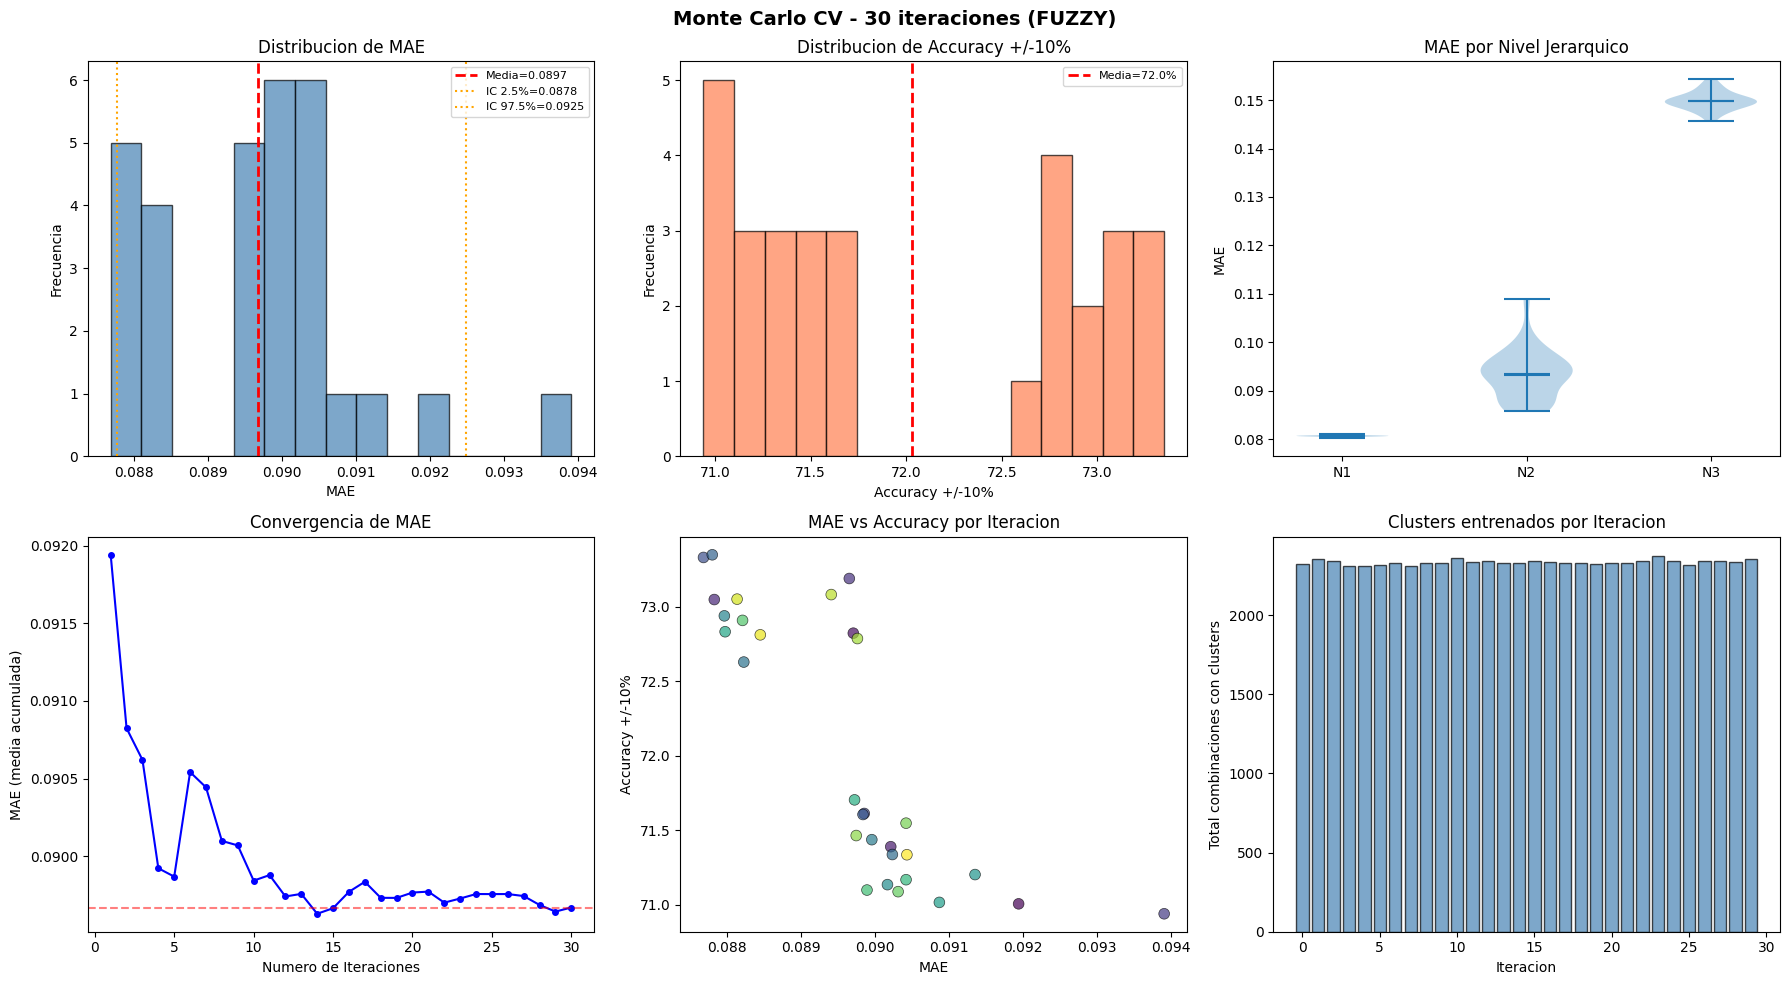

Visualizacion guardada en montecarlo_cv_resultados.png


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Monte Carlo CV - {N_ITERACIONES} iteraciones ({MEJOR_ALGORITMO.upper()})',
             fontsize=14, fontweight='bold')

# 1. Histograma de MAE
ax = axes[0, 0]
vals = df_resultados['mae'].dropna()
ax.hist(vals, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Media={vals.mean():.4f}')
ax.axvline(np.percentile(vals, 2.5), color='orange', linestyle=':', label=f'IC 2.5%={np.percentile(vals, 2.5):.4f}')
ax.axvline(np.percentile(vals, 97.5), color='orange', linestyle=':', label=f'IC 97.5%={np.percentile(vals, 97.5):.4f}')
ax.set_xlabel('MAE')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de MAE')
ax.legend(fontsize=8)

# 2. Histograma de Accuracy +/-10%
ax = axes[0, 1]
vals = df_resultados['acc_10'].dropna()
ax.hist(vals, bins=15, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Media={vals.mean():.1f}%')
ax.set_xlabel('Accuracy +/-10%')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de Accuracy +/-10%')
ax.legend(fontsize=8)

# 3. MAE por nivel (violin plot)
ax = axes[0, 2]
data_violin = []
labels_violin = []
for nivel, col in [('N1', 'mae_nivel1'), ('N2', 'mae_nivel2'), ('N3', 'mae_nivel3')]:
    vals = df_resultados[col].dropna()
    if len(vals) > 0:
        data_violin.append(vals.values)
        labels_violin.append(nivel)
if data_violin:
    parts = ax.violinplot(data_violin, showmeans=True, showmedians=True)
    ax.set_xticks(range(1, len(labels_violin)+1))
    ax.set_xticklabels(labels_violin)
ax.set_ylabel('MAE')
ax.set_title('MAE por Nivel Jerarquico')

# 4. Convergencia de MAE
ax = axes[1, 0]
mae_vals = df_resultados['mae'].values
mae_cumulative = np.cumsum(mae_vals) / np.arange(1, len(mae_vals)+1)
ax.plot(range(1, len(mae_vals)+1), mae_cumulative, 'b-o', markersize=4)
ax.axhline(mae_vals.mean(), color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Numero de Iteraciones')
ax.set_ylabel('MAE (media acumulada)')
ax.set_title('Convergencia de MAE')

# 5. Scatter MAE vs Accuracy
ax = axes[1, 1]
ax.scatter(df_resultados['mae'], df_resultados['acc_10'], alpha=0.7,
           c=range(N_ITERACIONES), cmap='viridis', s=60, edgecolors='black', linewidths=0.5)
ax.set_xlabel('MAE')
ax.set_ylabel('Accuracy +/-10%')
ax.set_title('MAE vs Accuracy por Iteracion')

# 6. Cobertura y clusters por iteracion
ax = axes[1, 2]
ax.bar(range(N_ITERACIONES), df_resultados['n_clusters_total'],
       alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Iteracion')
ax.set_ylabel('Total combinaciones con clusters')
ax.set_title('Clusters entrenados por Iteracion')

plt.tight_layout()
plt.savefig('montecarlo_cv_resultados.png', dpi=300, bbox_inches='tight')
plt.show()
print('Visualizacion guardada en montecarlo_cv_resultados.png')

In [37]:
# ============================================================================
# COMPARACION CON RESULTADOS v4
# ============================================================================
print('='*70)
print('COMPARACION CON RESULTADOS v4 (referencia)')
print('='*70)

# NOTA: El v4 evaluaba solo 2,000 muestras aleatorias del test (por velocidad).
# Este notebook evalua el test completo (PCT_TEST_EVALUAR configurable).
# Las metricas no son directamente comparables si PCT_TEST_EVALUAR != ~2.8%.
print(f'\nNOTA: v4 evaluo 2,000 muestras aleatorias del test.')
print(f'      MC evalua {len(test_firmas):,} casos ({PCT_TEST_EVALUAR*100:.0f}% del test).')
print(f'      Las metricas de Accuracy pueden diferir por el tamano de muestra.\n')

# Resultados del v4 (del paper verificado - sobre 2,000 muestras)
v4_mae = 0.0929
v4_acc10 = 73.6
v4_acc20 = 87.5

mc_mae = df_resultados['mae'].mean()
mc_acc10 = df_resultados['acc_10'].mean()
mc_acc20 = df_resultados['acc_20'].mean()

mae_ic = (np.percentile(df_resultados['mae'], 2.5), np.percentile(df_resultados['mae'], 97.5))
acc10_ic = (np.percentile(df_resultados['acc_10'], 2.5), np.percentile(df_resultados['acc_10'], 97.5))

print(f'{"Metrica":<20} {"v4 (2K)":>12} {"MC Media":>12} {"MC IC 95%":>20} {"v4 en IC?":>10}')
print('-'*76)

en_ic_mae = mae_ic[0] <= v4_mae <= mae_ic[1]
en_ic_acc = acc10_ic[0] <= v4_acc10 <= acc10_ic[1]

print(f'{"MAE":<20} {v4_mae:>12.4f} {mc_mae:>12.4f} [{mae_ic[0]:.4f}, {mae_ic[1]:.4f}] {"SI" if en_ic_mae else "NO":>10}')
print(f'{"Acc +/-10%":<20} {v4_acc10:>11.1f}% {mc_acc10:>11.1f}% [{acc10_ic[0]:.1f}%, {acc10_ic[1]:.1f}%] {"SI" if en_ic_acc else "NO":>10}')
print(f'{"Acc +/-20%":<20} {v4_acc20:>11.1f}% {mc_acc20:>11.1f}%')

print(f'\nConclusion:')
if en_ic_mae:
    print(f'  El MAE del v4 ({v4_mae:.4f}) CAE dentro del IC 95% de Monte Carlo.')
    print(f'  -> Los resultados del v4 son consistentes con la distribucion esperada.')
else:
    print(f'  El MAE del v4 ({v4_mae:.4f}) NO cae en el IC 95% [{mae_ic[0]:.4f}, {mae_ic[1]:.4f}].')
    if v4_mae > mae_ic[1]:
        print(f'  -> La estrategia global mejora respecto al v4 (Level 1 propagation).')
    else:
        print(f'  -> El v4 fue ligeramente mejor, posiblemente por suerte en los datos.')

COMPARACION CON RESULTADOS v4 (referencia)

NOTA: v4 evaluo 2,000 muestras aleatorias del test.
      MC evalua 72,253 casos (100% del test).
      Las metricas de Accuracy pueden diferir por el tamano de muestra.

Metrica                   v4 (2K)     MC Media            MC IC 95%  v4 en IC?
----------------------------------------------------------------------------
MAE                        0.0929       0.0897 [0.0878, 0.0925]         NO
Acc +/-10%                  73.6%        72.0% [71.0%, 73.3%]         NO
Acc +/-20%                  87.5%        88.3%

Conclusion:
  El MAE del v4 (0.0929) NO cae en el IC 95% [0.0878, 0.0925].
  -> La estrategia global mejora respecto al v4 (Level 1 propagation).


## 10. Resumen y Exportacion

In [38]:
# Guardar resultados
df_resultados.to_csv('resultados_montecarlo_cv.csv', index=False)
print('Resultados guardados en resultados_montecarlo_cv.csv')

# Resumen final
print()
print('='*70)
print('RESUMEN EJECUTIVO')
print('='*70)
print(f'Metodologia: Monte Carlo Cross-Validation ({N_ITERACIONES} iteraciones, {FRACCION_SUBSAMPLE*100:.0f}% subsample)')
print(f'Algoritmo global: {MEJOR_ALGORITMO.upper()}')
print(f'Hiperparametros: {MEJORES_PARAMS}')
print()
print(f'Metricas (media +/- std [IC 95%]):')

for metrica, nombre, fmt in [
    ('mae', 'MAE', '.4f'),
    ('acc_10', 'Accuracy +/-10pp', '.1f'),
    ('acc_20', 'Accuracy +/-20pp', '.1f'),
]:
    vals = df_resultados[metrica].dropna()
    media = vals.mean()
    std = vals.std()
    ic_inf = np.percentile(vals, 2.5)
    ic_sup = np.percentile(vals, 97.5)
    cv = std / media * 100
    suffix = '%' if 'acc' in metrica else ''
    print(f'  {nombre}: {media:{fmt}}{suffix} +/- {std:{fmt}}{suffix} '
          f'[{ic_inf:{fmt}}{suffix}, {ic_sup:{fmt}}{suffix}] (CV={cv:.1f}%)')

print(f'\nTiempo total: {tiempo_total/60:.1f} minutos')
print(f'Tiempo promedio por iteracion: {df_resultados["tiempo"].mean():.1f}s')

Resultados guardados en resultados_montecarlo_cv.csv

RESUMEN EJECUTIVO
Metodologia: Monte Carlo Cross-Validation (30 iteraciones, 70% subsample)
Algoritmo global: FUZZY
Hiperparametros: {'n_clusters': 4, 'm': 3.0, 'error': 0.005, 'maxiter': 1000}

Metricas (media +/- std [IC 95%]):
  MAE: 0.0897 +/- 0.0014 [0.0878, 0.0925] (CV=1.5%)
  Accuracy +/-10pp: 72.0% +/- 0.9% [71.0%, 73.3%] (CV=1.2%)
  Accuracy +/-20pp: 88.3% +/- 0.4% [87.6%, 88.7%] (CV=0.4%)

Tiempo total: 12.4 minutos
Tiempo promedio por iteracion: 24.9s


In [40]:
import pandas as pd

df = pd.read_csv('DS_Estadisticas_de_uso_BNe_Herramientas.csv')

# Fix mixed-type columns
df['Periodo'] = df['Periodo'].astype(str)

df.to_parquet('DS_Estadisticas_de_uso_BNe_Herramientas.parquet', engine='pyarrow', compression='snappy')

In [4]:
!uv add PyPDF2

Resolved 138 packages in 1.04s
Prepared 1 package in 107ms
Installed 1 package in 26ms
 + pypdf2==3.0.1


In [ ]:

from PyPDF2 import PdfReader, PdfWriter

input_path = "2025_05_13_Acta_Junta.pdf"
reader = PdfReader(input_path)
print(f"Total de páginas: {len(reader.pages)}")

ranges = [(189, 219), (401, 527)]

for i, (start, end) in enumerate(ranges, 1):
    writer = PdfWriter()
    for page_num in range(start - 1, end):
        writer.add_page(reader.pages[page_num])
    
    output = f"Parte_{i}_p{start}-{end}.pdf"
    with open(output, "wb") as f:
        writer.write(f)
    print(f"✅ Parte {i}: {output} ({end - start + 1} páginas)")

Total de páginas: 527
✅ Parte 1: Parte_1_p189-219.pdf (31 páginas)
✅ Parte 2: Parte_2_p401-527.pdf (127 páginas)


: 